## 1️⃣ Configuración del Entorno

In [4]:
# Instalación de dependencias
import subprocess
import sys

packages = [
    "spacy>=3.7.0",
    "networkx>=3.0.0", 
    "pyvis>=0.3.2",
    "plotly>=5.18.0",
    "matplotlib>=3.8.0"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q", "--trusted-host", "pypi.org", "--trusted-host", "files.pythonhosted.org"])

print("✓ Dependencias instaladas correctamente")

✓ Dependencias instaladas correctamente


In [2]:
# Imports principales
import os
import sys
import json
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass

# Suprimir warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Verificar versiones para evitar incompatibilidades
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 1.26.4
Pandas version: 2.3.3


In [5]:
# NLP
import spacy
from spacy import displacy

# Graph
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

print(f"spaCy version: {spacy.__version__}")
print(f"NetworkX version: {nx.__version__}")

spaCy version: 3.8.11
NetworkX version: 3.1


In [6]:
# Importar módulos del proyecto
from utils import (
    MythEntity, MythRelation, EntityType, RelationType, Mythology,
    build_networkx_graph, calculate_graph_metrics, get_node_color,
    get_edge_color, save_graph_to_json, load_graph_from_json,
    extract_relations_with_patterns, clean_text, detect_mythology,
    normalize_entity_name, identify_entity_type, create_sample_data,
    KNOWN_ENTITIES, FAMILY_PATTERNS, CONFLICT_PATTERNS
)

from mythology_knowledge_graph import MythologyKnowledgeGraph

print("✓ Módulos del proyecto cargados correctamente")

✓ Módulos del proyecto cargados correctamente


In [7]:
# Configuración de directorios
BASE_DIR = Path(os.getcwd())
DATA_DIR = BASE_DIR / "data"
CONFIG_DIR = BASE_DIR / "config"
OUTPUT_DIR = BASE_DIR / "outputs"

# Crear directorios si no existen
for dir_path in [DATA_DIR, CONFIG_DIR, OUTPUT_DIR, OUTPUT_DIR / "graphs"]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio base: {BASE_DIR}")
print(f"📁 Datos: {DATA_DIR}")
print(f"📁 Configuración: {CONFIG_DIR}")
print(f"📁 Salidas: {OUTPUT_DIR}")

📁 Directorio base: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge
📁 Datos: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\data
📁 Configuración: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\config
📁 Salidas: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs


## 2️⃣ Carga de Datos Mitológicos

In [8]:
# Cargar datos de ejemplo
sample_data_path = DATA_DIR / "sample_mythology.json"

if sample_data_path.exists():
    with open(sample_data_path, 'r', encoding='utf-8') as f:
        mythology_data = json.load(f)
    print(f"✓ Datos cargados desde: {sample_data_path}")
    print(f"  - Entidades: {len(mythology_data.get('entities', []))}")
    print(f"  - Relaciones: {len(mythology_data.get('relations', []))}")
    print(f"  - Textos: {len(mythology_data.get('texts', []))}")
else:
    print("⚠️ Archivo de datos no encontrado. Usando datos de ejemplo.")
    mythology_data = {"entities": [], "relations": [], "texts": []}

✓ Datos cargados desde: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\data\sample_mythology.json
  - Entidades: 20
  - Relaciones: 21
  - Textos: 4


In [9]:
# Vista previa de entidades
entities_df = pd.DataFrame(mythology_data.get('entities', []))
if not entities_df.empty:
    print("📊 Entidades Mitológicas:")
    display(entities_df[['name', 'type', 'mythology']].head(10))

📊 Entidades Mitológicas:


,name,type,mythology
0,Zeus,DEITY,Greek
1,Poseidon,DEITY,Greek
2,Hades,DEITY,Greek
3,Hera,DEITY,Greek
4,Athena,DEITY,Greek
5,Apollo,DEITY,Greek
6,Artemis,DEITY,Greek
7,Heracles,HERO,Greek
8,Perseus,HERO,Greek
9,Achilles,HERO,Greek


In [10]:
# Vista previa de relaciones
relations_df = pd.DataFrame(mythology_data.get('relations', []))
if not relations_df.empty:
    print("🔗 Relaciones:")
    display(relations_df.head(10))

🔗 Relaciones:


,source,target,type
0,Zeus,Poseidon,SIBLING_OF
1,Zeus,Hades,SIBLING_OF
2,Zeus,Hera,SPOUSE_OF
3,Zeus,Heracles,FATHER_OF
4,Zeus,Perseus,FATHER_OF
5,Zeus,Athena,FATHER_OF
6,Zeus,Apollo,FATHER_OF
7,Zeus,Artemis,FATHER_OF
8,Zeus,Mount Olympus,RULES
9,Poseidon,Zeus,SIBLING_OF


In [11]:
# Vista previa de textos
texts = mythology_data.get('texts', [])
if texts:
    print("📜 Textos Mitológicos:")
    for i, text in enumerate(texts[:3], 1):
        title = text.get('title', f'Texto {i}')
        content = text.get('content', '')[:150] + "..."
        print(f"\n{i}. {title}")
        print(f"   {content}")

📜 Textos Mitológicos:

1. The Olympian Gods
   Zeus, the king of the Olympian gods, ruled from Mount Olympus. He was the father of many heroes, including Heracles and Perseus. Zeus had two brothers...

2. The Twelve Labors
   Heracles, son of Zeus and the mortal Alcmene, was the greatest Greek hero. He completed twelve labors as penance. Among these, he killed the Hydra, a ...

3. Perseus and Medusa
   Perseus, another son of Zeus, was sent on a quest to slay Medusa, one of the three Gorgon sisters. With gifts from the gods, including winged sandals ...


## 3️⃣ Procesamiento de Lenguaje Natural (NLP)

In [16]:
# Cargar modelo de spaCy
# Intentar cargar modelo existente, si no existe, crear uno básico

try:
    nlp = spacy.load("en_core_web_sm")
    print(f"✓ Modelo spaCy cargado: en_core_web_sm")
    print(f"  - Pipeline: {nlp.pipe_names}")
except OSError:
    print("⚠️ Modelo en_core_web_sm no disponible.")
    print("   Creando modelo básico de spaCy en inglés...")
    # Crear un modelo básico de spaCy sin dependencias externas
    nlp = spacy.blank("en")
    # Agregar componentes básicos
    nlp.add_pipe("sentencizer")
    print(f"✓ Modelo básico de spaCy creado")
    print(f"  - Pipeline: {nlp.pipe_names}")
    print("  - Nota: Para NER avanzado, ejecutar en terminal:")
    print("    python -m spacy download en_core_web_sm")

✓ Modelo spaCy cargado: en_core_web_sm
  - Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [17]:
# Texto de ejemplo para demostración
demo_text = """
Zeus, the king of the Olympian gods, ruled from Mount Olympus. 
He was the father of many heroes, including Heracles and Perseus.
Zeus had two brothers: Poseidon, god of the sea, and Hades, ruler of the underworld.

Heracles, son of Zeus and the mortal Alcmene, completed twelve labors.
He killed the Hydra, a nine-headed serpent, and captured Cerberus from the underworld.

Perseus, another son of Zeus, slew Medusa the Gorgon and used her head as a weapon.
He later rescued Andromeda from a sea monster sent by Poseidon.

The Titans, including Cronus and Rhea, were the parents of Zeus, Poseidon, and Hades.
Zeus defeated Cronus and imprisoned the Titans in Tartarus.
"""

print("📜 Texto de demostración:")
print(demo_text)

📜 Texto de demostración:

Zeus, the king of the Olympian gods, ruled from Mount Olympus. 
He was the father of many heroes, including Heracles and Perseus.
Zeus had two brothers: Poseidon, god of the sea, and Hades, ruler of the underworld.

Heracles, son of Zeus and the mortal Alcmene, completed twelve labors.
He killed the Hydra, a nine-headed serpent, and captured Cerberus from the underworld.

Perseus, another son of Zeus, slew Medusa the Gorgon and used her head as a weapon.
He later rescued Andromeda from a sea monster sent by Poseidon.

The Titans, including Cronus and Rhea, were the parents of Zeus, Poseidon, and Hades.
Zeus defeated Cronus and imprisoned the Titans in Tartarus.



In [18]:
# Procesar texto con spaCy
doc = nlp(demo_text)

# Extraer entidades nombradas
print("🏷️ Entidades detectadas por spaCy:")
print("="*50)

spacy_entities = []
for ent in doc.ents:
    spacy_entities.append({
        "text": ent.text,
        "label": ent.label_,
        "start": ent.start_char,
        "end": ent.end_char
    })
    print(f"  {ent.text:20} → {ent.label_}")

print(f"\nTotal: {len(spacy_entities)} entidades")

🏷️ Entidades detectadas por spaCy:
  Zeus                 → PERSON
  Olympian             → NORP
  Mount Olympus        → GPE
  Heracles             → GPE
  Zeus                 → PERSON
  two                  → CARDINAL
  Poseidon             → PERSON
  Hades                → FAC
  Heracles             → PERSON
  Zeus                 → PERSON
  Alcmene              → ORG
  twelve               → CARDINAL
  Hydra                → PERSON
  nine                 → CARDINAL
  Cerberus             → PERSON
  Zeus                 → PERSON
  Medusa               → ORG
  Gorgon               → ORG
  Andromeda            → PERSON
  Poseidon             → PERSON
  Titans               → NORP
  Cronus               → FAC
  Rhea                 → PERSON
  Zeus                 → PERSON
  Poseidon             → PERSON
  Hades                → LOC
  Zeus                 → PERSON
  Titans               → NORP
  Tartarus             → GPE

Total: 29 entidades


In [19]:
# Visualizar entidades en contexto
displacy.render(doc, style="ent", jupyter=True)

In [20]:
# Buscar entidades mitológicas conocidas en el texto
print("🔍 Búsqueda de entidades mitológicas conocidas:")
print("="*50)

text_lower = demo_text.lower()
found_entities = []

for mythology, entities_by_type in KNOWN_ENTITIES.items():
    for entity_type, entity_list in entities_by_type.items():
        for entity_name in entity_list:
            if entity_name.lower() in text_lower:
                found_entities.append({
                    "name": entity_name,
                    "type": entity_type.value,
                    "mythology": mythology.value
                })

found_df = pd.DataFrame(found_entities)
if not found_df.empty:
    display(found_df.drop_duplicates())
    print(f"\nTotal: {len(found_df.drop_duplicates())} entidades mitológicas encontradas")

🔍 Búsqueda de entidades mitológicas conocidas:


,name,type,mythology
0,Zeus,DEITY,Greek
1,Hera,DEITY,Greek
2,Poseidon,DEITY,Greek
3,Hades,DEITY,Greek
4,Cronus,TITAN,Greek
5,Rhea,TITAN,Greek
6,Heracles,HERO,Greek
7,Perseus,HERO,Greek
8,Medusa,CREATURE,Greek
9,Hydra,CREATURE,Greek



Total: 15 entidades mitológicas encontradas


## 4️⃣ Extracción de Relaciones

In [21]:
# Extraer relaciones usando patrones
entity_names = {e["name"] for e in found_entities}

relations = extract_relations_with_patterns(demo_text, entity_names)

print("🔗 Relaciones extraídas:")
print("="*50)

for rel in relations:
    print(f"  {rel.source} --[{rel.relation_type.value}]--> {rel.target}")
    print(f"    Confianza: {rel.confidence:.2f}")
    print(f"    Fuente: '{rel.source_text}'")
    print()

print(f"Total: {len(relations)} relaciones")

🔗 Relaciones extraídas:
  Was --[FATHER_OF]--> Many
    Confianza: 0.80
    Fuente: 'was the father of many'

  He --[FATHER_OF]--> Many
    Confianza: 0.80
    Fuente: 'He was the father of many'

  Heracles --[FATHER_OF]--> Zeus
    Confianza: 0.80
    Fuente: 'Heracles, son of Zeus'

  Another --[FATHER_OF]--> Zeus
    Confianza: 0.80
    Fuente: 'another son of Zeus'

  Heracles --[MOTHER_OF]--> The
    Confianza: 0.80
    Fuente: 'Heracles, son of Zeus and the'

  He --[KILLED]--> The
    Confianza: 0.75
    Fuente: 'He killed the'

  Zeus --[KILLED]--> Cronus
    Confianza: 0.75
    Fuente: 'Zeus defeated Cronus'

Total: 7 relaciones


In [22]:
# Visualizar patrones de relaciones
print("📋 Patrones de relaciones disponibles:")
print("="*50)

print("\n🏠 PATRONES FAMILIARES:")
for rel_type, patterns in FAMILY_PATTERNS.items():
    print(f"  {rel_type.upper()}:")
    for p in patterns[:2]:
        print(f"    - {p}")

print("\n⚔️ PATRONES DE CONFLICTO:")
for rel_type, patterns in CONFLICT_PATTERNS.items():
    print(f"  {rel_type.upper()}:")
    for p in patterns[:2]:
        print(f"    - {p}")

📋 Patrones de relaciones disponibles:

🏠 PATRONES FAMILIARES:
  FATHER:
    - (\w+),?\s+(?:the\s+)?father\s+of\s+(\w+)
    - (\w+)\s+was\s+(?:the\s+)?father\s+(?:of|to)\s+(\w+)
  MOTHER:
    - (\w+),?\s+(?:the\s+)?mother\s+of\s+(\w+)
    - (\w+)\s+was\s+(?:the\s+)?mother\s+(?:of|to)\s+(\w+)
  SIBLING:
    - (\w+)\s+and\s+(\w+)\s+were\s+(?:brothers|sisters|siblings)
    - (\w+),?\s+(?:brother|sister)\s+of\s+(\w+)
  SPOUSE:
    - (\w+)\s+(?:married|wed)\s+(\w+)
    - (\w+),?\s+(?:wife|husband)\s+of\s+(\w+)

⚔️ PATRONES DE CONFLICTO:
  KILLED:
    - (\w+)\s+(?:killed|slew|slayed|defeated)\s+(\w+)
    - (\w+)\s+was\s+(?:killed|slain)\s+by\s+(\w+)
  RIVAL:
    - (\w+)\s+(?:rival|enemy|foe)\s+(?:of|to)\s+(\w+)
    - (\w+)\s+and\s+(\w+)\s+were\s+(?:rivals|enemies)
  ALLY:
    - (\w+)\s+(?:allied|joined)\s+(?:with)?\s*(\w+)
    - (\w+)\s+and\s+(\w+)\s+(?:fought\s+together|allied)


## 5️⃣ Construcción del Knowledge Graph

In [23]:
# Crear instancia del sistema
mkg = MythologyKnowledgeGraph(
    spacy_model="en_core_web_sm",
    use_transformers=False  # Cambiar a True si se tienen recursos de GPU
)

print("✓ Sistema MythologyKnowledgeGraph inicializado")

2026-01-06 14:58:52,588 - INFO - MythologyKnowledgeGraph inicializado


✓ Sistema MythologyKnowledgeGraph inicializado


In [24]:
# Procesar el texto de demostración
entities, relations = mkg.process_text(demo_text)

print(f"\n📊 Resultados del procesamiento:")
print(f"  - Entidades: {len(entities)}")
print(f"  - Relaciones: {len(relations)}")

2026-01-06 14:58:56,456 - INFO - Procesando texto...
2026-01-06 14:58:56,457 - INFO - Extrayendo entidades...
2026-01-06 14:58:56,458 - INFO - Cargando modelo spaCy: en_core_web_sm
2026-01-06 14:58:57,223 - INFO - Modelo spaCy cargado exitosamente
2026-01-06 14:58:57,277 - INFO -   → 24 entidades encontradas
2026-01-06 14:58:57,278 - INFO - Extrayendo relaciones...
2026-01-06 14:58:57,282 - INFO -   → 7 relaciones encontradas



📊 Resultados del procesamiento:
  - Entidades: 24
  - Relaciones: 7


In [25]:
# Ver entidades extraídas
print("\n🏛️ Entidades extraídas:")
print("="*50)

entities_list = []
for e in entities:
    entities_list.append({
        "Nombre": e.name,
        "Tipo": e.entity_type.value,
        "Mitología": e.mythology.value
    })

entities_extracted_df = pd.DataFrame(entities_list)
display(entities_extracted_df)


🏛️ Entidades extraídas:


,Nombre,Tipo,Mitología
0,Zeus,DEITY,Greek
1,Olympian,DEITY,Greek
2,Mount Olympus,DEITY,Greek
3,Heracles,HERO,Greek
4,Two,DEITY,Greek
5,Poseidon,DEITY,Greek
6,Hades,DEITY,Greek
7,Alcmene,DEITY,Greek
8,Twelve,DEITY,Greek
9,Hydra,CREATURE,Greek


In [26]:
# Ver relaciones extraídas
print("\n🔗 Relaciones extraídas:")
print("="*50)

relations_list = []
for r in relations:
    relations_list.append({
        "Origen": r.source,
        "Relación": r.relation_type.value,
        "Destino": r.target,
        "Confianza": f"{r.confidence:.2f}"
    })

relations_extracted_df = pd.DataFrame(relations_list)
display(relations_extracted_df)


🔗 Relaciones extraídas:


,Origen,Relación,Destino,Confianza
0,Was,FATHER_OF,Many,0.80
1,He,FATHER_OF,Many,0.80
2,Heracles,FATHER_OF,Zeus,0.80
3,Another,FATHER_OF,Zeus,0.80
4,Heracles,MOTHER_OF,The,0.80
5,He,KILLED,The,0.75
6,Zeus,KILLED,Cronus,0.75


In [27]:
# Construir el grafo
G = mkg.build_graph()

# Calcular métricas
metrics = calculate_graph_metrics(G)

print("\n📈 Métricas del Grafo:")
print("="*50)
for key, value in metrics.items():
    print(f"  {key}: {value}")

2026-01-06 14:59:12,173 - INFO - Construyendo grafo...
2026-01-06 14:59:12,176 - INFO - Grafo construido: 29 nodos, 7 aristas



📈 Métricas del Grafo:
  num_nodes: 29
  num_edges: 7
  density: 0.008620689655172414
  is_connected: False
  most_connections_in: Zeus
  most_connections_out: Heracles
  num_components: 22


## 6️⃣ Visualización del Grafo

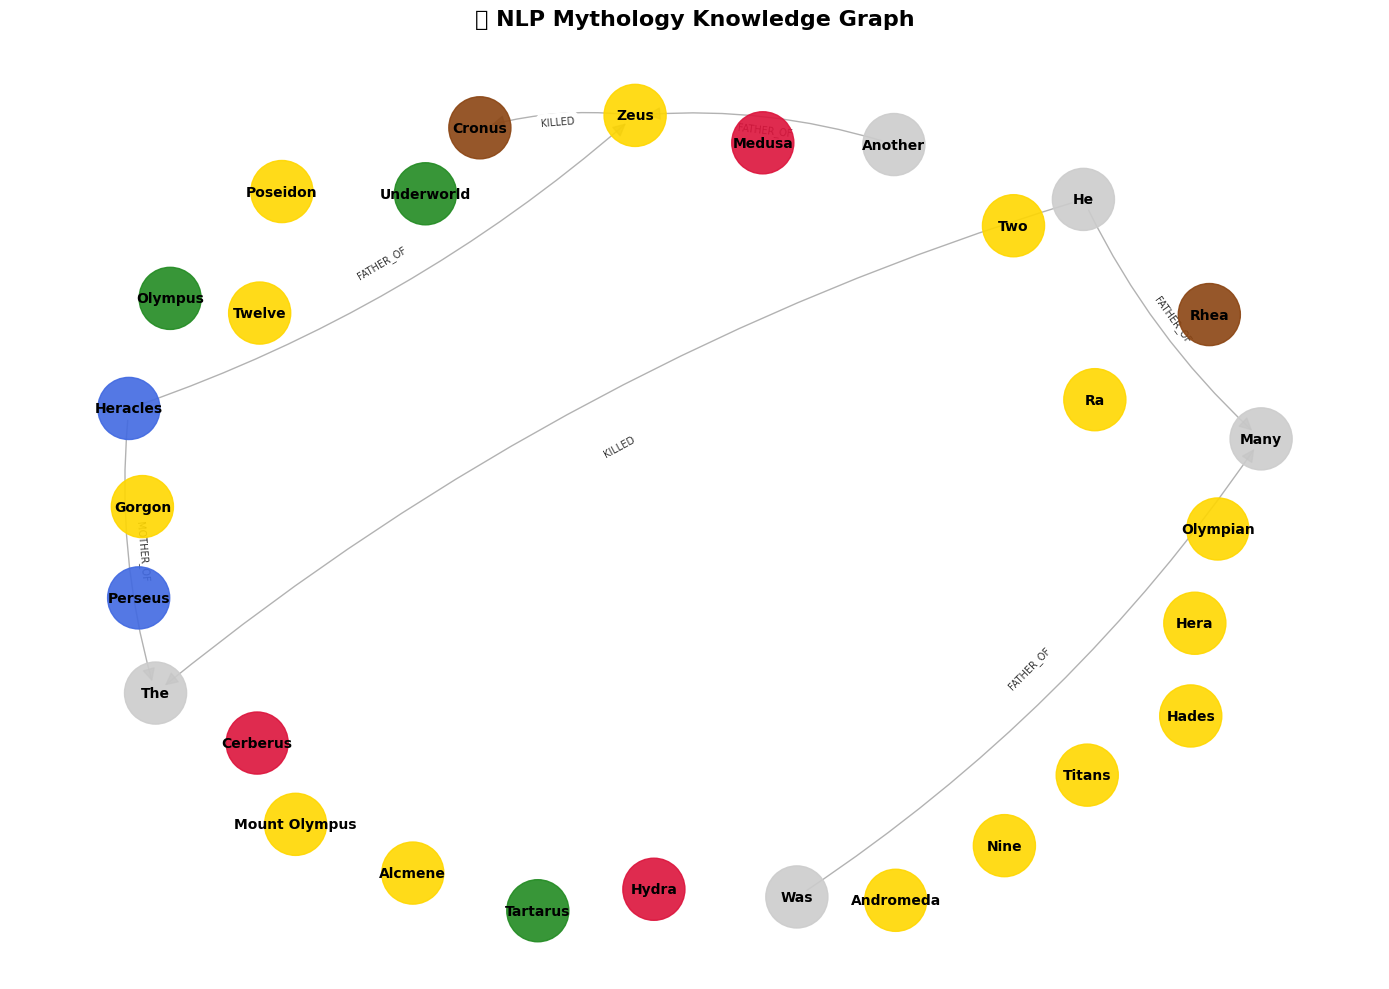


✓ Imagen guardada en: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs\mythology_graph_static.png


In [28]:
# Visualización con NetworkX y Matplotlib
plt.figure(figsize=(14, 10))

# Obtener colores de nodos basados en tipo de entidad
node_colors = []
for node in G.nodes():
    entity_type = G.nodes[node].get('entity_type', 'UNKNOWN')
    node_colors.append(get_node_color(entity_type))

# Layout del grafo
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.9)

# Dibujar aristas
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                        arrowsize=20, alpha=0.6, connectionstyle="arc3,rad=0.1")

# Dibujar etiquetas de nodos
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Dibujar etiquetas de aristas
edge_labels = {(u, v): d.get('relation_type', '')[:10] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, alpha=0.8)

plt.title("🏛️ NLP Mythology Knowledge Graph", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()

# Guardar figura
plt.savefig(OUTPUT_DIR / "mythology_graph_static.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Imagen guardada en: {OUTPUT_DIR / 'mythology_graph_static.png'}")

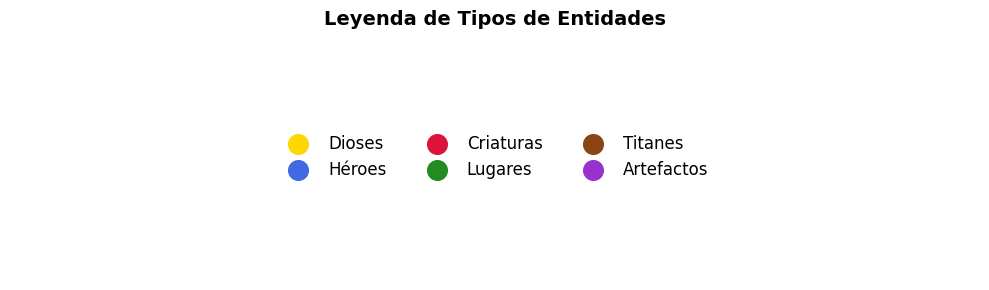

In [29]:
# Crear leyenda de colores
fig, ax = plt.subplots(figsize=(10, 3))

entity_types = [
    ("DEITY", "Dioses"),
    ("HERO", "Héroes"),
    ("CREATURE", "Criaturas"),
    ("LOCATION", "Lugares"),
    ("TITAN", "Titanes"),
    ("ARTIFACT", "Artefactos")
]

for i, (etype, label) in enumerate(entity_types):
    color = get_node_color(etype)
    ax.scatter([], [], c=color, s=200, label=label)

ax.legend(loc='center', ncol=3, fontsize=12, frameon=False)
ax.axis('off')
plt.title("Leyenda de Tipos de Entidades", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Visualización interactiva con PyVis
try:
    from pyvis.network import Network
    
    # Crear grafo interactivo
    html_path = str(OUTPUT_DIR / "mythology_graph_interactive.html")
    mkg.visualize_graph(html_path)
    
    print(f"\n✓ Grafo interactivo guardado en: {html_path}")
    print("  Abrir en el navegador para explorar interactivamente.")
    
except ImportError:
    print("⚠️ PyVis no está instalado. Instalar con: pip install pyvis")

2026-01-06 14:59:29,791 - INFO - Generando visualización...
2026-01-06 14:59:30,180 - INFO - Visualización guardada en: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs\mythology_graph_interactive.html



✓ Grafo interactivo guardado en: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs\mythology_graph_interactive.html
  Abrir en el navegador para explorar interactivamente.


## 7️⃣ Análisis del Grafo

In [31]:
# Análisis de centralidad
print("📊 Análisis de Centralidad:")
print("="*50)

if G.number_of_nodes() > 0:
    # Degree centrality
    degree_cent = nx.degree_centrality(G)
    sorted_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)
    
    print("\n🔝 Top 5 por Centralidad de Grado:")
    for node, cent in sorted_degree[:5]:
        print(f"  {node}: {cent:.3f}")
    
    # In-degree (quién recibe más conexiones)
    in_degree = dict(G.in_degree())
    sorted_in = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)
    
    print("\n📥 Top 5 por Conexiones Entrantes:")
    for node, deg in sorted_in[:5]:
        print(f"  {node}: {deg}")
    
    # Out-degree (quién genera más conexiones)
    out_degree = dict(G.out_degree())
    sorted_out = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)
    
    print("\n📤 Top 5 por Conexiones Salientes:")
    for node, deg in sorted_out[:5]:
        print(f"  {node}: {deg}")

📊 Análisis de Centralidad:

🔝 Top 5 por Centralidad de Grado:
  Zeus: 0.107
  Heracles: 0.071
  Many: 0.071
  He: 0.071
  The: 0.071

📥 Top 5 por Conexiones Entrantes:
  Zeus: 2
  Many: 2
  The: 2
  Cronus: 1
  Olympian: 0

📤 Top 5 por Conexiones Salientes:
  Heracles: 2
  He: 2
  Zeus: 1
  Was: 1
  Another: 1


In [32]:
# Distribución de tipos de entidades
entity_types_count = {}
for node, data in G.nodes(data=True):
    etype = data.get('entity_type', 'UNKNOWN')
    entity_types_count[etype] = entity_types_count.get(etype, 0) + 1

# Gráfico de barras
fig = px.bar(
    x=list(entity_types_count.keys()),
    y=list(entity_types_count.values()),
    color=list(entity_types_count.keys()),
    color_discrete_map={k: get_node_color(k) for k in entity_types_count.keys()},
    title="Distribución de Tipos de Entidades",
    labels={"x": "Tipo de Entidad", "y": "Cantidad"}
)
fig.update_layout(showlegend=False)
fig.show()

In [33]:
# Distribución de tipos de relaciones
relation_types_count = {}
for u, v, data in G.edges(data=True):
    rtype = data.get('relation_type', 'UNKNOWN')
    relation_types_count[rtype] = relation_types_count.get(rtype, 0) + 1

# Gráfico de pie
fig = px.pie(
    values=list(relation_types_count.values()),
    names=list(relation_types_count.keys()),
    title="Distribución de Tipos de Relaciones",
    hole=0.3
)
fig.show()

## 8️⃣ Exportación de Resultados

In [34]:
# Guardar resultados
output_files = mkg.save(str(OUTPUT_DIR), prefix="greek_mythology")

print("💾 Archivos generados:")
print("="*50)
for file_type, path in output_files.items():
    print(f"  📄 {file_type}: {path}")

2026-01-06 14:59:49,735 - INFO - Generando visualización...
2026-01-06 14:59:49,764 - INFO - Visualización guardada en: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs\greek_mythology_visualization.html
2026-01-06 14:59:49,766 - INFO - Archivos guardados en: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs


💾 Archivos generados:
  📄 json: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs\greek_mythology_graph.json
  📄 cypher: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs\greek_mythology_cypher.txt
  📄 html: c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\10_NLP_Mythology_Knowledge\outputs\greek_mythology_visualization.html


In [35]:
# Resumen final
summary = mkg.get_summary()

print("\n📋 RESUMEN DEL KNOWLEDGE GRAPH")
print("="*50)
print(f"\n📊 Totales:")
print(f"  - Entidades: {summary['total_entities']}")
print(f"  - Relaciones: {summary['total_relations']}")

print(f"\n🏛️ Entidades por Tipo:")
for etype, count in summary['entities_by_type'].items():
    print(f"  - {etype}: {count}")

print(f"\n🔗 Relaciones por Tipo:")
for rtype, count in summary['relations_by_type'].items():
    print(f"  - {rtype}: {count}")

print(f"\n🌍 Entidades por Mitología:")
for myth, count in summary['entities_by_mythology'].items():
    print(f"  - {myth}: {count}")

print(f"\n📈 Métricas del Grafo:")
for metric, value in summary['graph_metrics'].items():
    print(f"  - {metric}: {value}")


📋 RESUMEN DEL KNOWLEDGE GRAPH

📊 Totales:
  - Entidades: 24
  - Relaciones: 7

🏛️ Entidades por Tipo:
  - DEITY: 14
  - HERO: 2
  - CREATURE: 3
  - TITAN: 2
  - LOCATION: 3

🔗 Relaciones por Tipo:
  - FATHER_OF: 4
  - MOTHER_OF: 1
  - KILLED: 2

🌍 Entidades por Mitología:
  - Greek: 23
  - Egyptian: 1

📈 Métricas del Grafo:
  - num_nodes: 29
  - num_edges: 7
  - density: 0.008620689655172414
  - is_connected: False
  - most_connections_in: Zeus
  - most_connections_out: Heracles
  - num_components: 22


## 9️⃣ Consultas al Grafo

In [36]:
# Función para consultar el grafo
def query_graph(G, entity_name: str):
    """Consulta información de una entidad en el grafo."""
    if entity_name not in G.nodes():
        print(f"❌ Entidad '{entity_name}' no encontrada en el grafo.")
        return
    
    print(f"\n🔍 Información de: {entity_name}")
    print("="*50)
    
    # Atributos del nodo
    attrs = G.nodes[entity_name]
    print(f"\n📋 Atributos:")
    for key, value in attrs.items():
        print(f"  - {key}: {value}")
    
    # Relaciones salientes
    out_edges = list(G.out_edges(entity_name, data=True))
    if out_edges:
        print(f"\n📤 Relaciones salientes ({len(out_edges)}):")
        for _, target, data in out_edges:
            rel_type = data.get('relation_type', 'UNKNOWN')
            print(f"  → {target} ({rel_type})")
    
    # Relaciones entrantes
    in_edges = list(G.in_edges(entity_name, data=True))
    if in_edges:
        print(f"\n📥 Relaciones entrantes ({len(in_edges)}):")
        for source, _, data in in_edges:
            rel_type = data.get('relation_type', 'UNKNOWN')
            print(f"  ← {source} ({rel_type})")

# Ejemplo de consulta
query_graph(G, "Zeus")


🔍 Información de: Zeus

📋 Atributos:
  - entity_type: DEITY
  - mythology: Greek
  - aliases: []
  - attributes: {}
  - description: Extracted from: 'Zeus, the king of the Olympian gods, ruled from Mount Olympus....'

📤 Relaciones salientes (1):
  → Cronus (KILLED)

📥 Relaciones entrantes (2):
  ← Heracles (FATHER_OF)
  ← Another (FATHER_OF)


In [37]:
# Consultar otras entidades
query_graph(G, "Heracles")


🔍 Información de: Heracles

📋 Atributos:
  - entity_type: HERO
  - mythology: Greek
  - aliases: []
  - attributes: {}
  - description: Extracted from: 'He was the father of many heroes, including Heracles and Perseus....'

📤 Relaciones salientes (2):
  → Zeus (FATHER_OF)
  → The (MOTHER_OF)


In [38]:
# Encontrar caminos entre entidades
def find_path(G, source: str, target: str):
    """Encuentra el camino más corto entre dos entidades."""
    try:
        path = nx.shortest_path(G, source, target)
        print(f"\n🛤️ Camino de {source} a {target}:")
        print(" → ".join(path))
        return path
    except nx.NetworkXNoPath:
        print(f"❌ No hay camino de {source} a {target}")
        return None
    except nx.NodeNotFound as e:
        print(f"❌ Nodo no encontrado: {e}")
        return None

# Ejemplo
find_path(G, "Zeus", "Hydra")

❌ No hay camino de Zeus a Hydra


## 🔟 Conclusiones y Próximos Pasos

### ✅ Logros de este proyecto:

1. **Extracción de Entidades (NER):**
   - Identificación de dioses, héroes, criaturas y lugares mitológicos
   - Combinación de spaCy con diccionario de entidades conocidas

2. **Extracción de Relaciones:**
   - Patrones regex para relaciones familiares y de conflicto
   - Detección de parentesco, rivalidades y alianzas

3. **Knowledge Graph:**
   - Construcción con NetworkX
   - Visualización estática e interactiva
   - Análisis de centralidad y métricas

4. **Exportación:**
   - JSON para intercambio de datos
   - Cypher para Neo4j
   - HTML interactivo

### 🚀 Próximos pasos:

- [ ] Integrar modelos transformer de HuggingFace para mejor extracción
- [ ] Añadir soporte para más mitologías (nórdica, egipcia)
- [ ] Implementar interfaz web con Streamlit
- [ ] Conectar con Neo4j para consultas avanzadas
- [ ] Entrenar modelo NER personalizado para entidades mitológicas

In [39]:
# Mensaje final
print("""
╔════════════════════════════════════════════════════════════════╗
║                                                                ║
║   🏛️ NLP MYTHOLOGY KNOWLEDGE GRAPH - COMPLETADO               ║
║                                                                ║
║   Autor: César Adrián Delgado Díaz                            ║
║   Portfolio: https://tu-portfolio.com                         ║
║   LinkedIn: linkedin.com/in/cesar-delgado-diaz                ║
║   GitHub: github.com/cesar530                                  ║
║                                                                ║
║   Licencia: MIT                                                ║
║                                                                ║
╚════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════╗
║                                                                ║
║   🏛️ NLP MYTHOLOGY KNOWLEDGE GRAPH - COMPLETADO               ║
║                                                                ║
║   Autor: César Adrián Delgado Díaz                            ║
║   Portfolio: https://tu-portfolio.com                         ║
║   LinkedIn: linkedin.com/in/cesar-delgado-diaz                ║
║   GitHub: github.com/cesar530                                  ║
║                                                                ║
║   Licencia: MIT                                                ║
║                                                                ║
╚════════════════════════════════════════════════════════════════╝

